# EDA - Laps

In [285]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

## Initial EDA
### Goal of this analysis
The purpose of this EDA is to understand lap performance, identify patterns across drivers and seasons, and prepare clean data for further analysis and visualization.

In [286]:
con = duckdb.connect("../data/monza_f1_data.duckdb")

In [287]:
con.execute("SELECT COUNT(*) FROM laps").df()

,count_star()
0,7928


In [288]:
con.execute("DESCRIBE laps").df()["column_name"]

0           meeting_key
1           session_key
2         driver_number
3            lap_number
4            date_start
5     duration_sector_1
6     duration_sector_2
7     duration_sector_3
8              i1_speed
9              i2_speed
10       is_pit_out_lap
11         lap_duration
12    segments_sector_1
13    segments_sector_2
14    segments_sector_3
15             st_speed
Name: column_name, dtype: str

In [289]:
display(con.execute("DESCRIBE laps").df())

,column_name,column_type,null,key,default,extra
0,meeting_key,BIGINT,YES,None,None,None
1,session_key,BIGINT,YES,None,None,None
2,driver_number,BIGINT,YES,None,None,None
3,lap_number,BIGINT,YES,None,None,None
4,date_start,VARCHAR,YES,None,None,None
5,duration_sector_1,DOUBLE,YES,None,None,None
6,duration_sector_2,DOUBLE,YES,None,None,None
7,duration_sector_3,DOUBLE,YES,None,None,None
8,i1_speed,DOUBLE,YES,None,None,None
9,i2_speed,DOUBLE,YES,None,None,None


In [290]:
con.execute("""
    SELECT driver_number, COUNT(*) AS lap_count
    FROM laps
    GROUP BY driver_number
    ORDER BY lap_count DESC
""").df()

,driver_number,lap_count
0,55,438
1,16,436
2,44,426
3,1,423
4,4,421
5,23,408
6,10,401
7,63,400
8,81,394
9,31,384


In [291]:
display(con.execute("SELECT * FROM laps LIMIT 5").df())

,meeting_key,session_key,driver_number,lap_number,date_start,duration_sector_1,duration_sector_2,duration_sector_3,i1_speed,i2_speed,is_pit_out_lap,lap_duration,segments_sector_1,segments_sector_2,segments_sector_3,st_speed
0,1218,9150,4,1,NaN,NaN,45.313,46.844,286.0,206.0,True,NaN,"[--, 2064, 2049, 2049, 2049, 2049, 2049, 2049]","[2049, 2049, 2049, 2051, 2049, 2049, 2049]","[2049, 2049, 2049, 2049, 2049, 2049, 2049, 204...",99.0
1,1218,9150,34,1,2023-09-01T11:30:06.290000+00:00,NaN,31.420,30.451,309.0,316.0,True,NaN,"[2064, 2064, 2049, 2049, 2049, 2049, 2049, 2049]","[2049, 2049, 2051, 2049, 2051, 2051, 2051]","[2051, 2051, 2051, 2051, 2051, 2051, 2051, 205...",101.0
2,1218,9150,14,1,2023-09-01T11:30:14.414000+00:00,NaN,42.430,33.624,285.0,250.0,True,NaN,"[2064, 2064, 2049, 2049, 2049, 2049, 2049, 2049]","[2049, 2049, 2049, 2049, 2049, 2049, 2049]","[2049, 2049, 2049, 2049, 2049, 2049, 2049, 204...",232.0
3,1218,9150,22,1,2023-09-01T11:30:17.992000+00:00,NaN,41.429,45.863,291.0,302.0,True,NaN,"[2064, 2064, 2049, 2049, 2049, 2049, 2049, 2049]","[2049, 2049, 2049, 2049, 2049, 2049, 2049]","[2049, 2049, 2049, 2049, 2049, 2049, 2049, 204...",224.0
4,1218,9150,44,1,2023-09-01T11:30:23.024000+00:00,NaN,35.108,34.255,301.0,309.0,True,NaN,"[2064, 2064, 2049, 2049, 2049, 2049, 2049, 2049]","[2049, 2049, 2049, 2049, 2049, 2049, 2049]","[2049, 2049, 2049, 2049, 2049, 2049, 2049, 205...",245.0


In [292]:
con.execute("""
    SELECT
            COUNT (*) AS total,
            COUNT (*) - COUNT(lap_duration) AS nan_laptime,
            COUNT (*) - COUNT(duration_sector_1) AS nan_laptime_sector1,
            COUNT (*) - COUNT(duration_sector_2) AS nan_laptime_sector2,
            COUNT (*) - COUNT(duration_sector_3) AS nan_laptime_sector3,
            SUM(CASE WHEN is_pit_out_lap = true THEN 1 ELSE 0 END) AS pit_out_lap
    FROM laps
""").df()

,total,nan_laptime,nan_laptime_sector1,nan_laptime_sector2,nan_laptime_sector3,pit_out_lap
0,7928,398,973,96,158,1225.0


## Data cleaning
- Filter out pit out-lap and rows without lap-time sins these may compromise and affect values furthere down the line

In [293]:
laps_clean = con.execute("""
    SELECT * FROM laps
    WHERE lap_duration IS NOT NULL
      AND duration_sector_1 IS NOT NULL AND NOT isnan(duration_sector_1)
      AND duration_sector_2 IS NOT NULL AND NOT isnan(duration_sector_2)
      AND duration_sector_3 IS NOT NULL AND NOT isnan(duration_sector_3)
      AND is_pit_out_lap = false
""").df()

total = con.execute("SELECT COUNT(*) FROM laps").fetchone()[0]
print(f"laps before cleaning: {total}")
print(f"laps after cleaning:  {len(laps_clean)}")
print(f"deleted rows:       {total - len(laps_clean)}")

laps before cleaning: 7928
laps after cleaning:  6553
deleted rows:       1375


In [294]:
print(laps_clean.shape)
print(laps_clean.isna().sum())

(6553, 16)
meeting_key            0
session_key            0
driver_number          0
lap_number             0
date_start             0
duration_sector_1      0
duration_sector_2      0
duration_sector_3      0
i1_speed             670
i2_speed               0
is_pit_out_lap         0
lap_duration           0
segments_sector_1      0
segments_sector_2      0
segments_sector_3      0
st_speed             470
dtype: int64


In [295]:
laps_clean = laps_clean.dropna(subset=["i1_speed", "st_speed"])

print(laps_clean.shape)
print(laps_clean[["i1_speed", "st_speed"]].isna().sum())

(5552, 16)
i1_speed    0
st_speed    0
dtype: int64


In [296]:
laps_clean.info()
laps_clean.describe()

<class 'pandas.DataFrame'>
Index: 5552 entries, 0 to 6551
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   meeting_key        5552 non-null   int64  
 1   session_key        5552 non-null   int64  
 2   driver_number      5552 non-null   int64  
 3   lap_number         5552 non-null   int64  
 4   date_start         5552 non-null   str    
 5   duration_sector_1  5552 non-null   float64
 6   duration_sector_2  5552 non-null   float64
 7   duration_sector_3  5552 non-null   float64
 8   i1_speed           5552 non-null   float64
 9   i2_speed           5552 non-null   float64
 10  is_pit_out_lap     5552 non-null   bool   
 11  lap_duration       5552 non-null   float64
 12  segments_sector_1  5552 non-null   object 
 13  segments_sector_2  5552 non-null   object 
 14  segments_sector_3  5552 non-null   object 
 15  st_speed           5552 non-null   float64
dtypes: bool(1), float64(7), int64(4), object

,meeting_key,session_key,driver_number,lap_number,duration_sector_1,duration_sector_2,duration_sector_3,i1_speed,i2_speed,lap_duration,st_speed
count,5552.000000,5552.000000,5552.000000,5552.00000,5552.000000,5552.000000,5552.000000,5552.000000,5552.000000,5552.000000,5552.000000
mean,1243.355908,9548.846001,29.976045,17.12428,31.636869,32.644137,32.366806,288.617615,294.956772,96.834737,298.063581
std,20.759636,314.390758,24.186761,12.71090,8.502666,7.683504,7.581300,53.171018,53.876714,25.323524,60.037025
min,1218.000000,9150.000000,1.000000,1.00000,26.181000,26.340000,26.047000,74.000000,61.000000,78.792000,69.000000
25%,1218.000000,9157.000000,11.000000,7.00000,27.364000,28.327000,27.705000,292.000000,296.000000,83.531000,291.750000
50%,1244.000000,9585.000000,23.000000,14.00000,27.986000,29.483000,28.526000,312.000000,315.000000,86.209500,322.000000
75%,1268.000000,9906.000000,44.000000,23.00000,32.077750,33.435750,35.824500,318.000000,328.000000,105.604500,337.000000
max,1268.000000,9912.000000,89.000000,53.00000,96.104000,81.050000,72.280000,342.000000,347.000000,1129.701000,364.000000


In [297]:
print(laps_clean.shape)
print("\nMissing values per column:")
print(laps_clean.isna().sum())

print("\nMissing lap_duration values:")
print(laps_clean["lap_duration"].isna().sum())

(5552, 16)

Missing values per column:
meeting_key          0
session_key          0
driver_number        0
lap_number           0
date_start           0
duration_sector_1    0
duration_sector_2    0
duration_sector_3    0
i1_speed             0
i2_speed             0
is_pit_out_lap       0
lap_duration         0
segments_sector_1    0
segments_sector_2    0
segments_sector_3    0
st_speed             0
dtype: int64

Missing lap_duration values:
0


In [298]:
display(con.execute("SELECT * FROM laps_clean LIMIT 5").df())

,meeting_key,session_key,driver_number,lap_number,date_start,duration_sector_1,duration_sector_2,duration_sector_3,i1_speed,i2_speed,is_pit_out_lap,lap_duration,segments_sector_1,segments_sector_2,segments_sector_3,st_speed
0,1218,9150,34,2,2023-09-01T11:31:48.835000+00:00,28.539,30.043,37.088,298.0,312.0,False,95.670,"[2049, 2049, 2049, 2049, 2049, 2049, 2049, 2048]","[2049, 2049, 2049, 2049, 2049, 2049, 2048]","[2049, 2051, 2051, 2051, 2048, 2048, 2048, 204...",327.0
1,1218,9150,14,2,2023-09-01T11:32:04.428000+00:00,32.153,35.267,42.913,284.0,250.0,False,110.333,"[2049, 2049, 2049, 2048, 2048, 2048, 2049, 2049]","[2049, 2049, 2049, 2049, 2049, 2049, 2048]","[2049, 2048, 2048, 2049, 2049, 2048, 2048, 204...",276.0
2,1218,9150,44,2,2023-09-01T11:32:21.006000+00:00,27.957,28.557,27.915,314.0,324.0,False,84.429,"[2049, 2049, 2051, 2049, 2049, 2049, 2049, 2049]","[2051, 2049, 2049, 2049, 2049, 2049, 2049]","[2051, 2051, 2051, 2051, 2051, 2049, 2049, 204...",331.0
3,1218,9150,11,2,2023-09-01T11:32:23.975000+00:00,27.933,28.501,28.186,314.0,332.0,False,84.620,"[2049, 2051, 2049, 2049, 2049, 2049, 2049, 2049]","[2049, 2049, 2051, 2049, 2049, 2051, 2051]","[2049, 2049, 2049, 2049, 2049, 2051, 2049, 204...",341.0
4,1218,9150,1,2,2023-09-01T11:32:27.318000+00:00,28.101,28.533,28.335,310.0,331.0,False,84.969,"[2049, 2049, 2049, 2049, 2049, 2049, 2049, 2049]","[2049, 2049, 2049, 2051, 2051, 2049, 2049]","[2049, 2049, 2049, 2049, 2049, 2049, 2051, 205...",339.0


In [299]:
con.execute("CREATE OR REPLACE TABLE laps_clean AS SELECT * FROM laps_clean")

In [300]:
categorical_cols = ["driver_number", "session_key", "is_pit_out_lap"]

for col in categorical_cols:
    print(f"\nValue counts for {col}:")
    print(laps_clean[col].value_counts())


Value counts for driver_number:
driver_number
55    309
16    306
4     306
23    306
44    302
63    294
1     278
10    278
81    271
18    263
14    262
31    261
27    233
22    217
11    197
77    184
20    170
24    168
43    152
40    111
87    102
2      97
5      91
12     88
6      87
3      82
30     82
34     20
89     19
61     16
Name: count, dtype: int64

Value counts for session_key:
session_key
9157    699
9912    679
9590    671
9150    372
9906    370
9152    359
9905    354
9584    317
9907    310
9583    303
9585    261
9151    258
9153    220
9908    205
9586    174
Name: count, dtype: int64

Value counts for is_pit_out_lap:
is_pit_out_lap
False    5552
Name: count, dtype: int64


In [301]:
# Noticed some drivers have very few laps – might affect averages

lap_counts = laps_clean["driver_number"].value_counts()

valid_drivers = lap_counts[lap_counts > 20].index

filtered_df = laps_clean[laps_clean["driver_number"].isin(valid_drivers)]

filtered_df.groupby("driver_number")["lap_duration"].mean()

driver_number
1      95.960748
2      95.382722
3      93.943329
4      93.837350
5      95.406374
6      95.793126
10     98.727590
11     94.931883
12     97.576398
14     98.047095
16     95.807974
18    100.891795
20     98.023612
22     99.815226
23     94.334850
24     97.945399
27     96.540086
30     96.649829
31     98.137690
40     96.981685
43     96.545368
44     98.580570
55     97.234667
63     95.336173
77     95.867098
81     94.261749
87     96.543863
Name: lap_duration, dtype: float64

## Beskrivande stistik

In [302]:
con.execute("""
    SELECT
        COUNT(*)                                    AS totalt,
        COUNT(*) - COUNT(duration_sector_1)         AS nan_sector1,
        COUNT(*) - COUNT(duration_sector_2)         AS nan_sector2,
        COUNT(*) - COUNT(duration_sector_3)         AS nan_sector3,
        COUNT(*) - COUNT(lap_duration)              AS nan_laptime
    FROM laps_clean
""").df()

,totalt,nan_sector1,nan_sector2,nan_sector3,nan_laptime
0,6561,8,0,0,0


In [303]:
con.execute("""
    SELECT
            COUNT(*) AS totala_varv,
            COUNT(lap_duration) AS har_varvtid,
            COUNT(*) - COUNT(lap_duration) AS missing_laptime,
            COUNT(duration_sector_1) AS har_sector1,
            COUNT(duration_sector_2) AS har_sector2,
            COUNT(duration_sector_3) AS har_sector3,
    FROM laps_clean
""").df()

,totala_varv,har_varvtid,missing_laptime,har_sector1,har_sector2,har_sector3
0,6561,6561,0,6553,6561,6561


In [304]:
con.execute("""
    SELECT
            lap_number,
            driver_number,
            ROUND(lap_duration, 3) AS laptime,
            ROUND(duration_sector_1 + duration_sector_2 + duration_sector_3, 3) AS sum_sectorer,
            ROUND(lap_duration - (duration_sector_1 + duration_sector_2 + duration_sector_3) ,3) AS diffrence
    FROM laps_clean
    WHERE lap_duration IS NOT NULL
    AND duration_sector_1 IS NOT NULL
    AND duration_sector_2 IS NOT NULL
    AND duration_sector_3 IS NOT NULL
    LIMIT 10
""").df()

,lap_number,driver_number,laptime,sum_sectorer,diffrence
0,2,34,95.670,95.670,0.0
1,2,14,110.333,110.333,0.0
2,2,44,84.429,84.429,0.0
3,2,11,84.620,84.620,0.0
4,2,1,84.969,84.969,0.0
5,2,31,85.680,85.680,0.0
6,2,55,85.616,85.616,0.0
7,2,63,86.688,86.688,0.0
8,2,20,86.072,86.072,0.0
9,2,40,86.790,86.790,0.0


In [305]:
con.execute("""
    SELECT 
            s.session_name,
            s.year,
            ROUND(AVG(l.lap_duration) ,3) AS avgl_varvtid,
            ROUND(MIN(l.lap_duration) ,3) AS fastest,
            ROUND(MAX(l.lap_duration) ,3) AS slowest,
            ROUND(STDDEV(l.lap_duration) ,3) AS stddev,
            COUNT(*) AS lap_count
    FROM laps l
    JOIN session s ON l.session_key = s.session_key
    WHERE l.lap_duration IS NOT NULL
    GROUP BY s.session_name, s.year
    ORDER BY s.year, s.session_name
""").df()

,session_name,year,avgl_varvtid,fastest,slowest,stddev,lap_count
0,Practice 1,2023,150.902,82.657,1188.676,162.391,463
1,Practice 2,2023,200.762,81.355,1129.701,202.222,344
2,Practice 3,2023,153.248,80.912,1106.852,164.293,455
3,Qualifying,2023,170.029,80.294,684.691,150.033,298
4,Race,2023,87.772,85.072,113.593,3.606,948
5,Practice 1,2024,180.244,81.676,1267.910,229.478,390
6,Practice 2,2024,165.563,80.738,1462.684,205.520,418
7,Practice 3,2024,181.901,80.117,1124.302,193.412,364
8,Qualifying,2024,210.575,79.327,1446.253,233.740,246
9,Race,2024,85.798,81.432,120.178,4.238,1008


In [306]:
fastest_laps = con.execute("""
    SELECT
        s.year,
        d.full_name,
        d.team_name,
        ROUND(MIN(l.lap_duration) ,3) AS fastest_lap,
        ROUND(AVG(l.lap_duration) ,3) AS avg_lap
    FROM laps_clean l
    JOIN drivers d ON l.driver_number = d.driver_number
                AND l.session_key = d.session_key
    JOIN session s ON l.session_key = s.session_key
    WHERE l.lap_duration IS NOT NULL
        AND s.session_name = 'Race'
    GROUP BY s.year, d.full_name, d.team_name
    ORDER BY s.year, fastest_lap
""").df()

display(fastest_laps)

,year,full_name,team_name,fastest_lap,avg_lap
0,2023,Oscar PIASTRI,McLaren,85.072,87.144
1,2023,Max VERSTAPPEN,Red Bull Racing,85.240,86.314
2,2023,Carlos SAINZ,Ferrari,85.501,86.517
3,2023,Sergio PEREZ,Red Bull Racing,85.522,86.446
4,2023,Charles LECLERC,Ferrari,85.580,86.538
5,2023,Lewis HAMILTON,Mercedes,85.582,87.063
6,2023,Pierre GASLY,Alpine,85.758,87.463
7,2023,Liam LAWSON,AlphaTauri,85.842,87.316
8,2023,George RUSSELL,Mercedes,85.847,86.683
9,2023,Nico HULKENBERG,Haas F1 Team,85.894,87.656


## Visualisering

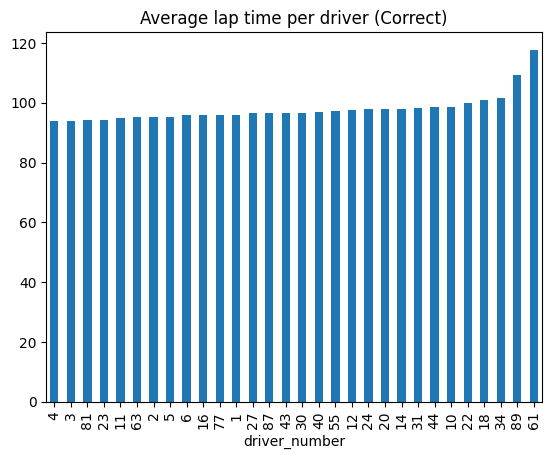

In [307]:
# Drivers with fewer laps may have less reliable average lap times.
laps_clean.groupby("driver_number")["lap_duration"].mean().sort_values().plot(kind="bar")
plt.title("Average lap time per driver (Correct)")
plt.show()

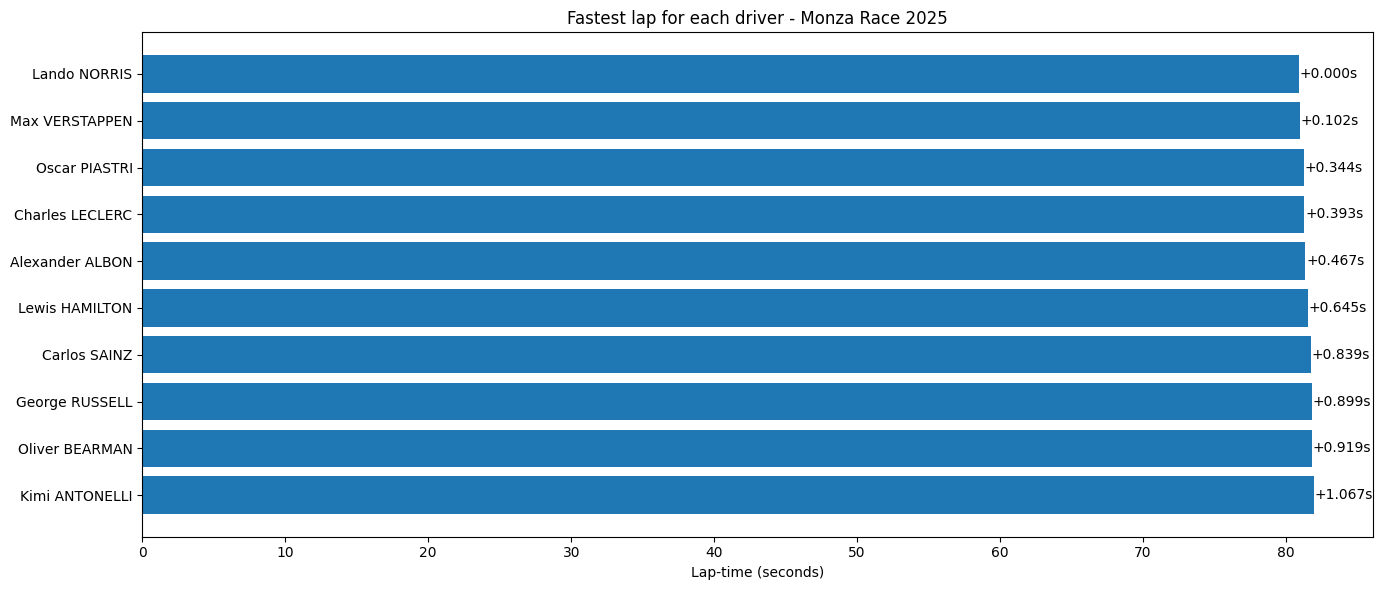

In [308]:
df_2025 = fastest_laps[fastest_laps["year"] == 2025].nsmallest(10, "fastest_lap")

fastest_time = df_2025["fastest_lap"].min()
df_2025["diff"] = df_2025["fastest_lap"] - fastest_time

fig, ax = plt.subplots(figsize=(14,6))

bars = ax.barh(df_2025["full_name"], df_2025["fastest_lap"])


for i, (time, diff) in enumerate(zip(df_2025["fastest_lap"], df_2025["diff"])):
    ax.text(time + 0.05, i, f"+{diff:.3f}s", va='center')

ax.set_xlabel("Lap-time (seconds)")
ax.set_title("Fastest lap for each driver - Monza Race 2025")
ax.invert_yaxis()

plt.tight_layout()

plt.savefig("fastest_lap.png", dpi=300)
plt.show()

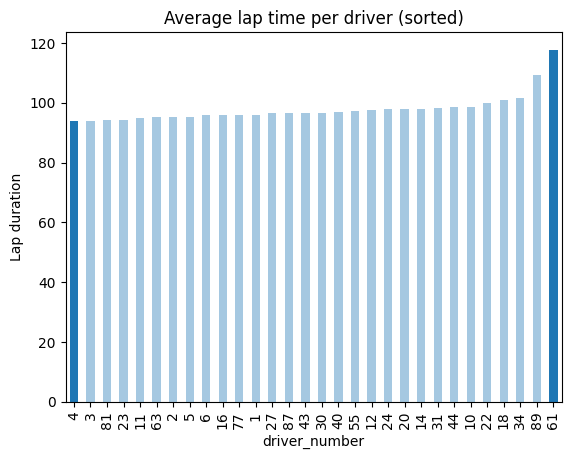

In [309]:
avg_laps = laps_clean.groupby("driver_number")["lap_duration"].mean().sort_values()

ax = avg_laps.plot(kind="bar")
plt.title("Average lap time per driver (sorted)")
plt.ylabel("Lap duration")

bars = ax.patches
bars[0].set_alpha(1)      
bars[-1].set_alpha(1)     

for bar in bars[1:-1]:
    bar.set_alpha(0.4)

plt.show()

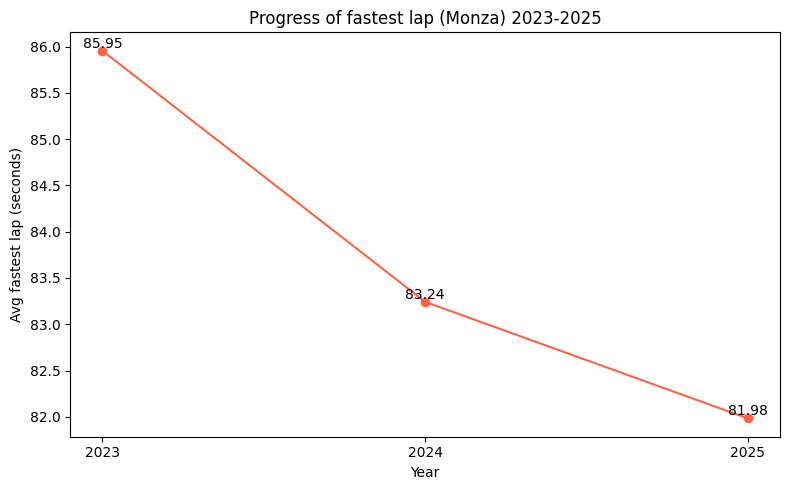

In [310]:
yearly = fastest_laps.groupby("year")["fastest_lap"].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(yearly["year"], yearly["fastest_lap"], marker='o', color="tomato")

for x, y in zip(yearly["year"], yearly["fastest_lap"]):
    ax.text(x, y, f"{y:.2f}", ha ='center', va='bottom')

ax.set_xlabel("Year")
ax.set_ylabel("Avg fastest lap (seconds)")
ax.set_title("Progress of fastest lap (Monza) 2023-2025")
ax.set_xticks(yearly["year"])

plt.tight_layout()

plt.savefig("fastest_lap_prog.png", dpi=300)
plt.show()

## Exporterar rensad data
- Spara den rensade datan som CSV för att kunna använda i PowerBI

In [311]:
laps_clean.to_csv("output/laps_clean.csv", index=False)
con.close()

In [312]:
# Create a simple selector table for dashboard
sector_df = pd.DataFrame({
    "sector_name": ["Sector 1", "Sector 2", "Sector 3", "Full Lap"]
})

sector_df.to_csv("output/sector_selector.csv", index=False)

## Julius Story telling graph


In [313]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import numpy as np

df = pd.read_csv("output/laps_with_positions.csv")

driver_names = {
    1: "VER", 11: "PER", 55: "SAI", 16: "LEC", 63: "RUS",
    44: "HAM", 23: "ALB", 4: "NOR", 14: "ALO", 77: "BOT",
    40: "LAW", 81: "PIA", 2: "SAR", 24: "ZHO", 10: "GAS",
    18: "STR", 27: "HUL", 20: "MAG", 31: "OCO", 22: "TSU",
    38: "BEA", 87: "ANT", 72: "BOT", 43: "COL", 6: "HAD"
}

df["acronym"] = df["driver_number"].map(driver_names).fillna(df["driver_number"].astype(str))

race_df = df[
    (df["session_type"] == "Race") &
    (df["lap_duration"].notna()) &
    (df["is_pit_out_lap"] == False)
].copy()

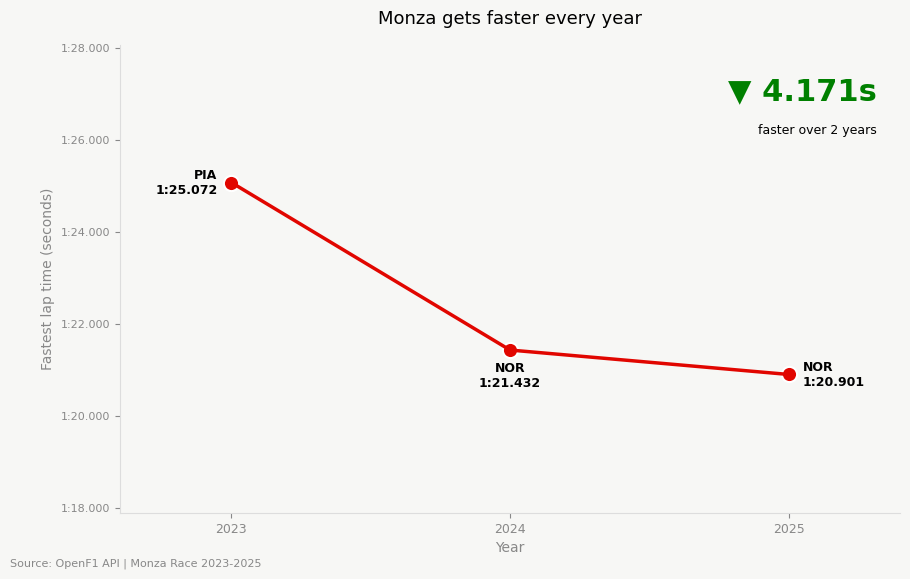

In [319]:
from matplotlib.ticker import FuncFormatter

yearly_fastest = (
    race_df.groupby("year")["lap_duration"]
    .min()
    .reset_index()
    .rename(columns={"lap_duration": "fastest_lap"})
)

def get_fastest_driver(year):
    year_df = race_df[race_df["year"] == year]
    min_idx = year_df["lap_duration"].idxmin()
    return year_df.loc[min_idx, "acronym"]

yearly_fastest["driver"] = yearly_fastest["year"].apply(get_fastest_driver)

def format_laptime(seconds):
    m = int(seconds // 60)
    s = seconds % 60
    return f"{m}:{s:06.3f}"

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("#f7f7f5")
ax.set_facecolor("#f7f7f5")

ax.plot(yearly_fastest["year"], yearly_fastest["fastest_lap"],
        color="#E10600", linewidth=2.5)

n = len(yearly_fastest)
for idx, (_, row) in enumerate(yearly_fastest.iterrows()):
    ax.scatter(row["year"], row["fastest_lap"],
               color="#E10600", s=120, edgecolors="white", linewidth=1.5)

    label = f"{row['driver']}\n{format_laptime(row['fastest_lap'])}"

    if idx == 0:
        ax.text(row["year"] - 0.05, row["fastest_lap"], label,
                ha="right", va="center", fontsize=9, fontweight="bold")
    elif idx == n - 1:

        ax.text(row["year"] + 0.05, row["fastest_lap"], label,
                ha="left", va="center", fontsize=9, fontweight="bold")
    else:
        ax.text(row["year"], row["fastest_lap"] - 0.25, label,
                ha="center", va="top", fontsize=9, fontweight="bold")

diff = yearly_fastest["fastest_lap"].iloc[0] - yearly_fastest["fastest_lap"].iloc[-1]

ax.text(0.97, 0.93, f"▼ {diff:.3f}s", transform=ax.transAxes,
        color="green", fontsize=22, fontweight="bold", ha="right", va="top")

ax.text(0.97, 0.83, f"faster over {n - 1} years", transform=ax.transAxes,
        color="black", fontsize=9, ha="right", va="top")

ax.set_title("Monza gets faster every year",
             fontsize=13, pad=15, loc="center")
ax.set_xlabel("Year", color="#888888")
ax.set_ylabel("Fastest lap time (seconds)", color="#888888")
ax.set_xticks(yearly_fastest["year"])

# Årtal samma färg som y-axelns tider
ax.tick_params(axis="x", colors="#888888", labelsize=9)
ax.tick_params(axis="y", colors="#888888", labelsize=8)

ax.yaxis.set_major_formatter(FuncFormatter(
    lambda t, _: format_laptime(t) if t > 60 else f"{t:.1f}"
))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_color("#dddddd")
ax.spines["left"].set_color("#dddddd")
ax.set_ylim(yearly_fastest["fastest_lap"].min() - 3,
            yearly_fastest["fastest_lap"].max() + 3)

# Sista punktens label behöver lite extra högermarginall
ax.set_xlim(yearly_fastest["year"].min() - 0.4,
            yearly_fastest["year"].max() + 0.4)

fig.text(0.01, 0.01, "Source: OpenF1 API | Monza Race 2023-2025",
         color="#888888", fontsize=8)

fig.subplots_adjust(left=0.12, right=0.90, top=0.88, bottom=0.1)
plt.savefig("output/storytelling_yearly_trend.png", dpi=150,
            bbox_inches="tight", facecolor="#f7f7f5")
plt.show()